In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from DNAnet.data.data_models.hid_image import HIDImage
from DNAnet.data.data_models.dna_models import Panel

from DNAnet.data.parsing import get_peak_data
from DNAnet.evaluation.visualizations import plot_profile
from DNAnet.data.data_models.dna_models import Annotation
from DNAnet.evaluation.visualizations import plot_profile_markers


import matplotlib.pyplot as plt
import numpy as np

# Create HID Image

In [ ]:


gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"
ppf6_panel_path = "resources/data/SGPanel_PPF6C_SPOOR.xml"

nfi_path = "resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 1/Inj5 2017-05-01-09-45-24-128/1A2_A01_01.hid"
ppf6_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USABLE - HID & PPF6 & GT (but in single_source ds) & PNL  - NIST Mixture_Profiles/Promega_PowerPlex_Fusion_6C/PPF6C_A1_3P-A_1-1-98_0.25_A01_01.hid"
gf_path = '/Users/amarmesic/Documents/tudelft/thesis/datasets/PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/B06_RD14-0003-48_49-1;4-M3c-0.075GF-Q0.8_02.5sec.hid'
local_gf_path = 'resources/data/ProvedIt/A02_RD14-0003-31_32-1;1-M2c-0.03GF-Q2.0_01.15sec.hid'

image = HIDImage(
    path=local_gf_path,
    panel=Panel(gf_panel_path),
    size_standard="GENESCAN_600_LIZ",
)

In [ ]:
from config_io import load_model

unet_model = load_model("config/models/unet.yaml")
unet_model.load("resources/model/current_best_unet/")
predictions = unet_model.predict_batch([image])

/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-01 18:37:36 INFO     Calling alleles from predicted segmentation...


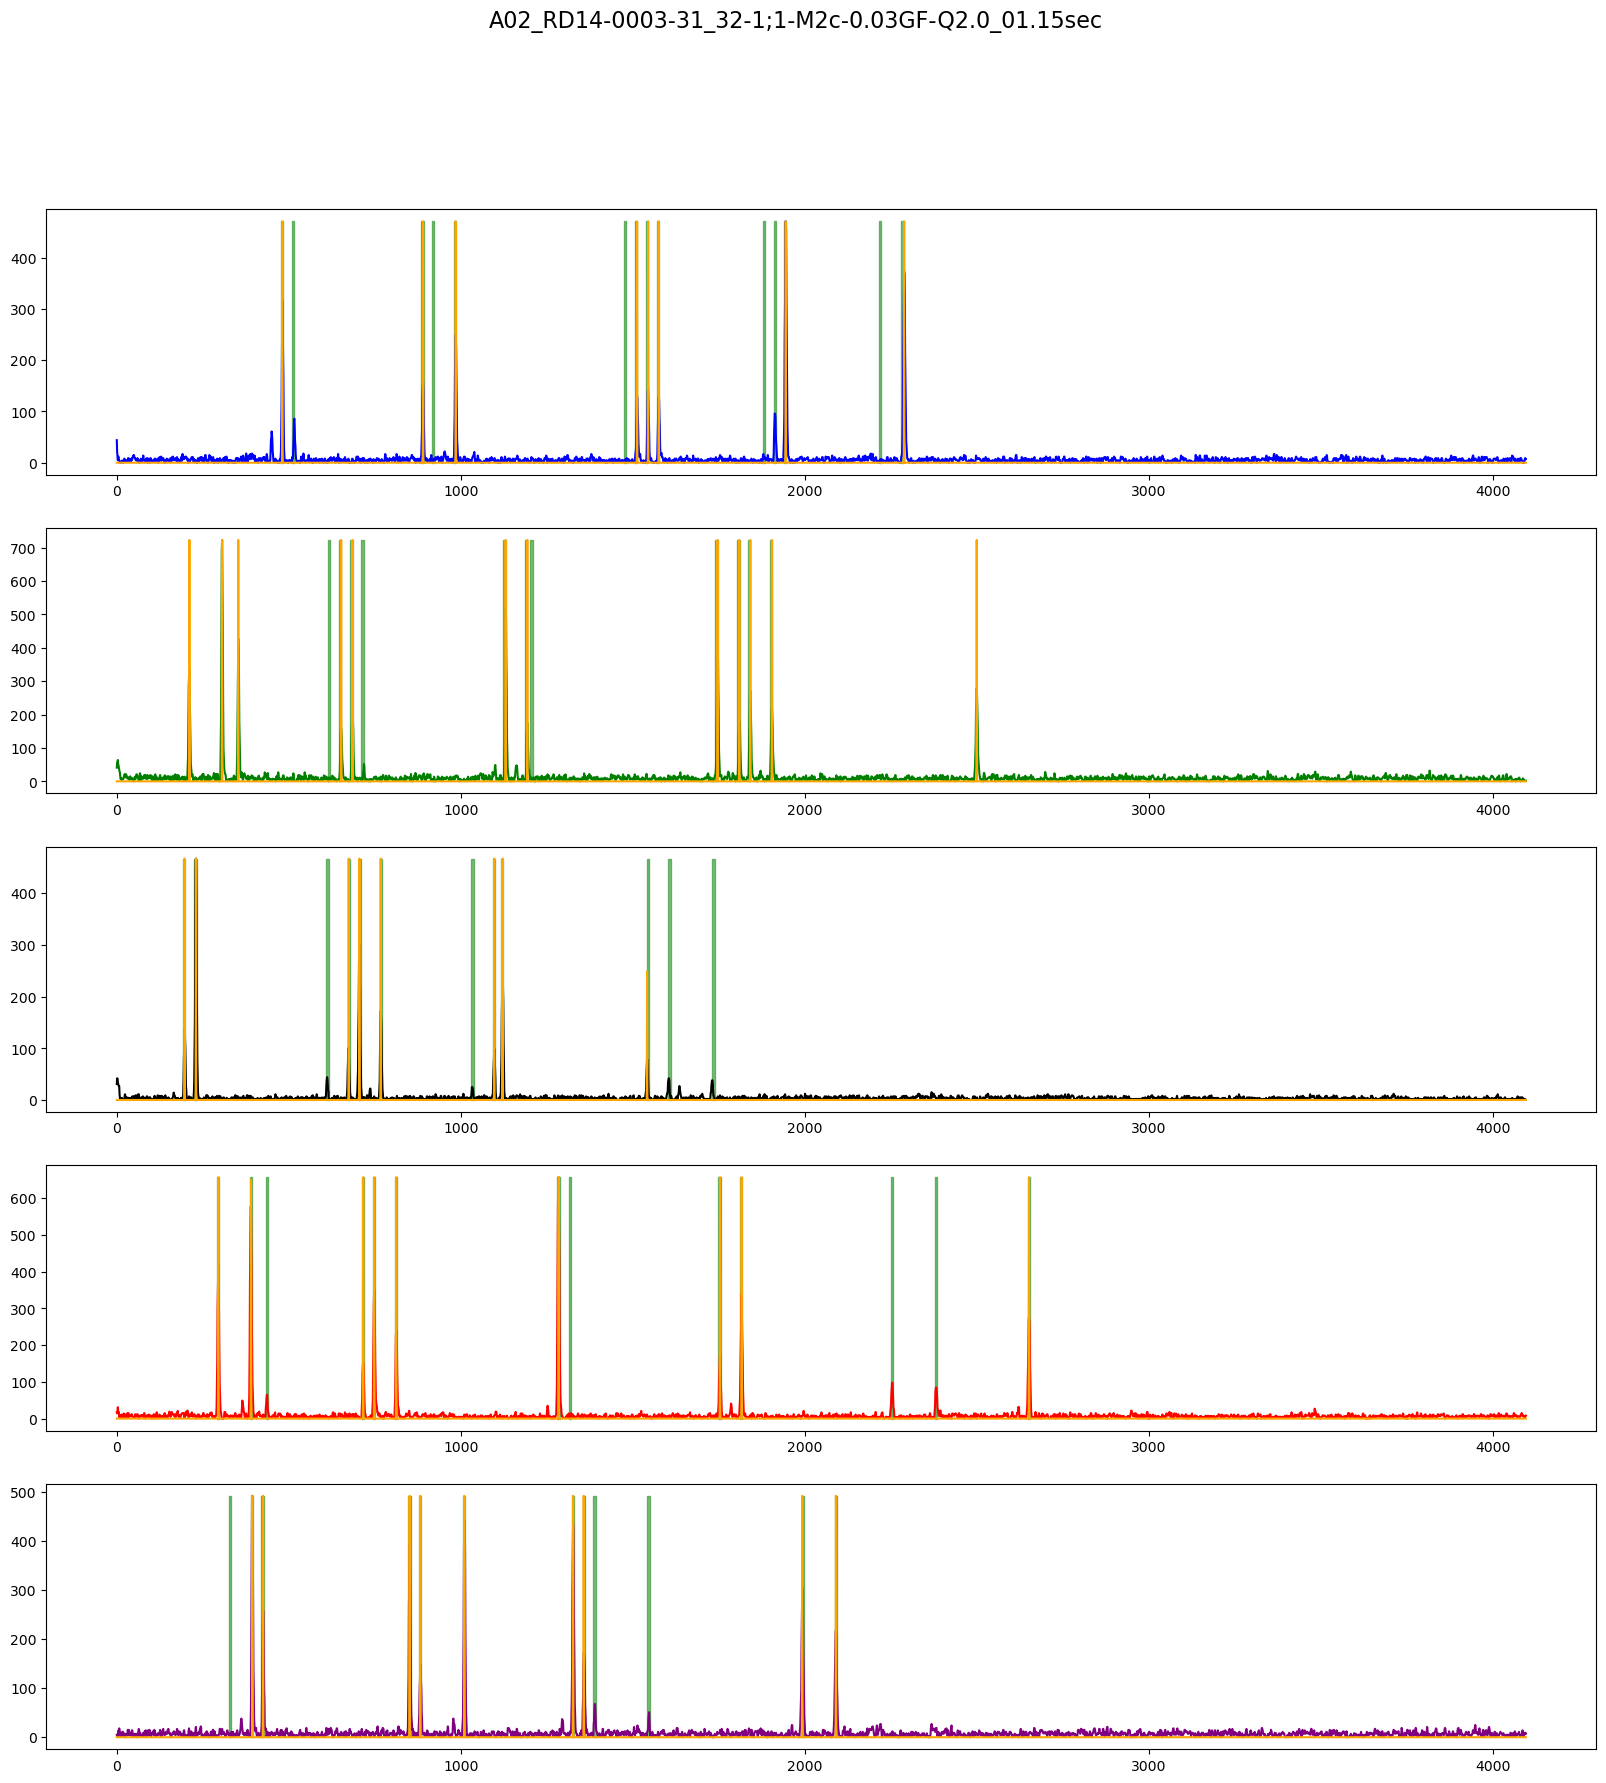

In [ ]:
plot_profile([image], predictions, prediction_as_mask=False)

In [ ]:
predictions[0]

Prediction(classification=None, image=[[[9.5347741e-06]
  [1.4781257e-09]
  [1.3866362e-06]
  ...
  [8.7548160e-06]
  [8.0537066e-06]
  [2.0663406e-06]]

 [[3.2299788e-08]
  [7.8347469e-08]
  [7.1116574e-07]
  ...
  [2.1122319e-06]
  [4.4194849e-06]
  [5.7329419e-07]]

 [[9.0579698e-07]
  [2.7992223e-07]
  [3.5918637e-07]
  ...
  [1.4068575e-06]
  [4.3302903e-06]
  [6.0904807e-07]]

 [[5.8483060e-06]
  [1.1936221e-07]
  [6.8641098e-06]
  ...
  [2.1772889e-06]
  [1.2044985e-06]
  [1.3860888e-06]]

 [[2.4791393e-06]
  [1.4556248e-06]
  [1.5713272e-06]
  ...
  [5.1234674e-06]
  [3.2407954e-06]
  [3.2824684e-07]]], meta={'original_image_path': PosixPath('resources/data/ProvedIt/A02_RD14-0003-31_32-1;1-M2c-0.03GF-Q2.0_01.15sec.hid'), 'called_alleles': [Marker(dye_row=0, name='D3S1358', alleles=[Allele(name='15', base_pair=None, left_bin=None, right_bin=None, height=317)]), Marker(dye_row=0, name='vWA', alleles=[Allele(name='18', base_pair=None, left_bin=None, right_bin=None, height=249), Al

In [ ]:
from DNAnet.evaluation.segmentation.allele_metrics import allele_f1_score, allele_precision, allele_recall

hid_dataset = [image]

print('allele u-net f1: ', allele_f1_score(hid_dataset, predictions))
print('allele u-net precision: ', allele_precision(hid_dataset, predictions))
print('allele u-net recall: ', allele_recall(hid_dataset, predictions))

allele u-net f1:  0.7777777777777777
allele u-net precision:  0.9130434782608695
allele u-net recall:  0.6774193548387096
